Title: demand_tst.ipynb

Purpose: This script is to test different population data??? and to make some appendix plots for the population data ie the fit curves and maybe a map

Author: Onno Nennecke on 04.03.2025 Modified: 17.03.2025

#### Load packages

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
# Load cdo package for regridding
from cdo import Cdo
cdo = Cdo()

In [ ]:
# Import code from vdW Paper
import Functions.demand as demand

##### Load population data from vdW Paper

In [4]:
demand_fit_values = xr.open_dataset('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/demand_fit_values.nc')
demand_population_t2m_grid = xr.open_dataset('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_t2m_grid.nc')
demand_population_t2m_grid_weights = xr.open_dataset('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_t2m_grid_weights.nc')

#### Get a feel for the data

In [4]:
# Check what is in the json file (just a dictionary with the countries) --> Germany is 9

'''
# open json file
import json
with open('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/dict_population_per_country.json') as f:
    regions = json.load(f)
    
regions
'''

"\n# open json file\nimport json\nwith open('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/dict_population_per_country.json') as f:\n    regions = json.load(f)\n    \nregions\n"

In [5]:
# Look into the structure of the demand_fit_values for Germany: 

# demand_fit_values.sel(country = 9, period = 'weekday')['a']
'''
for i in demand_fit_values.variables:
    print(i)
    print(demand_fit_values.sel(country = 9)[i].values)
'''

'\nfor i in demand_fit_values.variables:\n    print(i)\n    print(demand_fit_values.sel(country = 9)[i].values)\n'

In [6]:
demand_population_t2m_grid

<xarray.Dataset> Size: 25MB
Dimensions:     (lon: 429, lat: 185, country: 39)
Coordinates:
  * lon         (lon) float64 3kB -32.0 -31.75 -31.5 -31.25 ... 74.5 74.75 75.0
  * lat         (lat) float64 1kB 80.0 79.75 79.5 79.25 ... 34.5 34.25 34.0
  * country     (country) float64 312B 0.0 1.0 2.0 3.0 ... 36.0 37.0 38.0 39.0
Data variables:
    population  (country, lat, lon) float64 25MB ...
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Thu Sep 08 13:33:58 2022: cdo -O -f nc -remapsum,/Users/lie...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [7]:
# Define a rough area for Germany
n = 55.5
s = 47
w = 5.5
e = 15.5

demand_population_t2m_grid_de = demand_population_t2m_grid.sel( dict(country = 9, lat=slice(n,s), lon=slice(w,e)))['population']
demand_population_t2m_grid_weights_de = demand_population_t2m_grid_weights.sel( dict(country = 9, lat=slice(n,s), lon=slice(w,e)))['population']

Text(0.5, 1.0, 'demand_population_t2m_grid_weights_de')

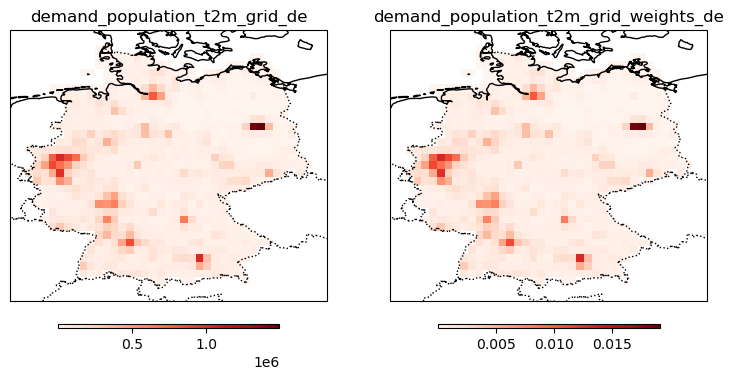

In [8]:
# Look at the population data
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.PlateCarree()})

#plotting
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im1 = ax1.pcolormesh(demand_population_t2m_grid_de.lon, demand_population_t2m_grid_de.lat, demand_population_t2m_grid_de.values, transform=ccrs.PlateCarree(), cmap='Reds')
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('demand_population_t2m_grid_de')


#plotting
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im2 = ax2.pcolormesh(demand_population_t2m_grid_weights_de.lon, demand_population_t2m_grid_weights_de.lat, demand_population_t2m_grid_weights_de.values, transform=ccrs.PlateCarree(), cmap='Reds')
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('demand_population_t2m_grid_weights_de')


##### Just some data checking

In [9]:
# Only ~78 Mio people in Germany
np.nansum(demand_population_t2m_grid_de.values) / 1000000


np.float64(78.18941650702027)

In [10]:
# count non nan values (number of cells) = Number of cells in germany
np.count_nonzero(~np.isnan(demand_population_t2m_grid_de.values))

776

In [11]:
# The Weights are just the normalized population values:

ratio = demand_population_t2m_grid_weights_de / demand_population_t2m_grid_de

# count the number of each value in ratio
unique, counts = np.unique(ratio.values, return_counts=True)
print(unique, counts)
# 1.27894547e-08

print(1 / np.nansum(demand_population_t2m_grid_de.values)) # = the weight values
print(np.nansum(demand_population_t2m_grid_de.values) * 1.27894547e-08) # = 1
print(np.nansum(demand_population_t2m_grid_weights_de.values)) # = 1

[1.27894547e-08 1.27894547e-08 1.27894547e-08            nan] [  1 524 251 659]
1.2789454694424208e-08
1.000000000435968
1.0


#### Load the climate data

In [12]:
# Load climate data
ESM = 'CESM2' 
run = 'r1i1p1f1' # r10i1p1f1  r11i1p1f1  r1i1p1f1  r2i1p1f1  r3i1p1f1  r4i1p1f1  r5i1p1f1  r6i1p1f1  r7i1p1f1  r8i1p1f1  r9i1p1f1

# create list of variables
variables = ['sfcWind', 'rsds', 'tas'] # Surface Wind Speed, Downward Short-Wave Radiation, Air Temperature, Maximum Air Temperature # , 'tas_max'

# Initialize variables (Just for code colouring)
sfcWind = 0
rsds = 0
tas = 0
tas_max = 0

# Load data
for variable in variables:
    nc = xr.open_mfdataset(f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/historical/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_historical_{run}_gn_*')
    # select variable
    globals()[variable] = nc[variable] 
    # filter winter
    globals()[variable] = globals()[variable][np.isin(globals()[variable].time.dt.month, [10,11,12,1,2,3]),:,:]
    # select region
    globals()[variable] = globals()[variable].sel(dict(lat=slice(s,n), lon=slice(w,e))) # At the moment roughly germany
    
if tas.units == 'K':
    tas.attrs['units']= '°C'
    tas = tas - 273.15

/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), n

In [13]:
population_grid_vdW = '/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_t2m_grid.nc'
# Determine directory for regridding
population_regrid_vdW = '/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_regrid.nc'

# Take the data from population_t2m_grid and regrid it to the same grid as the climate data (and save it to population_regrid.nc)
cdo.remapsum(
    '/climca/data/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/day/tas/gn/v20190308/tas_day_CESM2_historical_r1i1p1f1_gn_18500101-18591231.nc',
    input=population_grid_vdW,
    output=population_regrid_vdW,
    readCdf=True,
    options="-f nc",
)

'/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_regrid.nc'

In [14]:
population_regrid_vdW = xr.open_dataset(population_regrid_vdW)

### ISIMIP population data

In [15]:
import geopandas as gpd
from shapely.ops import unary_union

# Load the population data
population_isimip = xr.open_dataset('/home/onennecke/population/population_2015soc_30arcmin_annual_2015_2100.nc')

# Load the shapefile for Germany
germany_shapefile = gpd.read_file('/home/onennecke/population/VG250_STA.shp')

# Ensure the population data has the correct CRS
population_isimip = population_isimip.rio.write_crs("EPSG:4326")

# Unionize all features into one geometry
germany_geometry = unary_union(germany_shapefile.geometry)

# Clip the population data using the unionized Germany geometry
population_isimip_subset = population_isimip.rio.clip([germany_geometry], germany_shapefile.crs)

# Select the specific time
population_isimip_subset = population_isimip_subset.sel(time='2025-01-01T12:00:00')['total-population']


In [16]:
# Plot the whole data set: 

'''
ax = plt.axes(projection=ccrs.PlateCarree())
population_isimip.sel(dict(lat=slice(60,45), lon=slice(5,15), time='2025-01-01T12:00:00'))['total-population'].plot(ax=ax, transform=ccrs.PlateCarree())
#germany_population_cells.plot(ax=ax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')
ax.coastlines()
plt.show()
'''

"\nax = plt.axes(projection=ccrs.PlateCarree())\npopulation_isimip.sel(dict(lat=slice(60,45), lon=slice(5,15), time='2025-01-01T12:00:00'))['total-population'].plot(ax=ax, transform=ccrs.PlateCarree())\n#germany_population_cells.plot(ax=ax, transform=ccrs.PlateCarree())\nax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')\nax.coastlines()\nplt.show()\n"

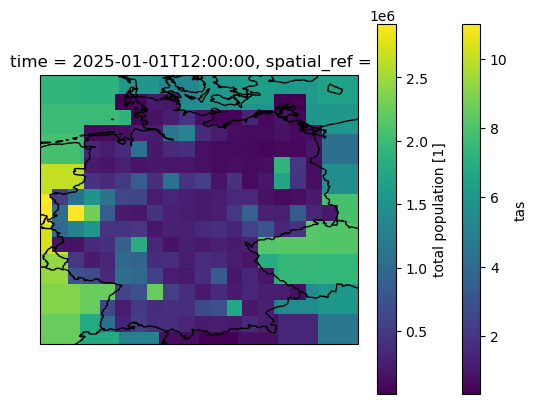

In [17]:
# Plot the clipped data set:
ax = plt.axes(projection=ccrs.PlateCarree())
tas.isel(time=0).plot(ax=ax, transform=ccrs.PlateCarree())

population_isimip_subset.plot(ax=ax, transform=ccrs.PlateCarree())
#germany_population_cells.plot(ax=ax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')
ax.coastlines()
plt.show()

In [18]:
np.nansum(population_isimip_subset.values) / 1000000

np.float32(84.673134)

In [19]:
# Save ISIMIP data to the demand folder
population_isimip_subset.to_netcdf('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_isimip_subset.nc')

In [ ]:
# Regrid the ISIMIP data to the same grid as the climate data

population_grid_ISIMIP = '/climca/people/onennecke/population_data/isimip_data/population_isimip_subset.nc'
# Determine directory for regridding
population_regrid_ISIMIP = '/climca/people/onennecke/population_data/isimip_data/population_regrid_ISIMIP.nc'

# Take the data from population_t2m_grid and regrid it to the same grid as the climate data (and save it to population_regrid.nc)

cdo.remapsum(
    '/climca/data/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/day/tas/gn/v20190308/tas_day_CESM2_historical_r1i1p1f1_gn_18500101-18591231.nc',
    input=population_grid_ISIMIP,
    output=population_regrid_ISIMIP,
    readCdf=True,
    options="-f nc",
)

'/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_regrid_ISIMIP.nc'

In [21]:
# Load the regridded ISIMIP data
population_regrid_ISIMIP = xr.open_dataset(population_regrid_ISIMIP)

#### Compare both regridded datasets

In [22]:
population_regrid_vdW_slice = population_regrid_vdW.sel(dict(lat=slice(s,n), lon=slice(w, e), country=9))['population']
population_regrid_ISIMIP_slice = population_regrid_ISIMIP.sel(dict(lat=slice(s,n), lon=slice(w, e)))['total-population']


In [23]:
population_regrid_vdW_slice
population_regrid_ISIMIP_slice
print(np.nansum(population_regrid_vdW_slice.values) / 1000000)
print(np.nansum(population_regrid_ISIMIP_slice.values) / 1000000)

78.18941650702027
80.01763


#### Calculate weights

In [24]:
population_regrid_vdW_slice_weights = population_regrid_vdW_slice / np.nansum(population_regrid_vdW_slice.values)
population_regrid_ISIMIP_slice_weights = population_regrid_ISIMIP_slice / np.nansum(population_regrid_ISIMIP_slice.values)

#### Calculate weighted sum

In [25]:
demand_list = []
for y in np.unique(tas["time.year"].values):
    # print(y)
    ds_demand0 = xr.Dataset()
    ds_demand0['temp'] = (tas.sel(time=str(y)) * population_regrid_vdW_slice_weights).sum(dim=['lat', 'lon'])
    demand_list.append(ds_demand0)
    
ds_demand = xr.concat(demand_list, dim="time") 
 

#### Calculate demand

In [31]:
ds_demand_actual = demand.compute_demand(ds_demand, demand_fit_values.sel(country = 9, period = 'weekday'))

In [34]:
ds_demand_actual['time'] = pd.to_datetime(ds_demand_actual['time'].values)
print(ds_demand_actual['time'].dtype)

TypeError: <class 'cftime._cftime.DatetimeNoLeap'> is not convertible to datetime, at position 0

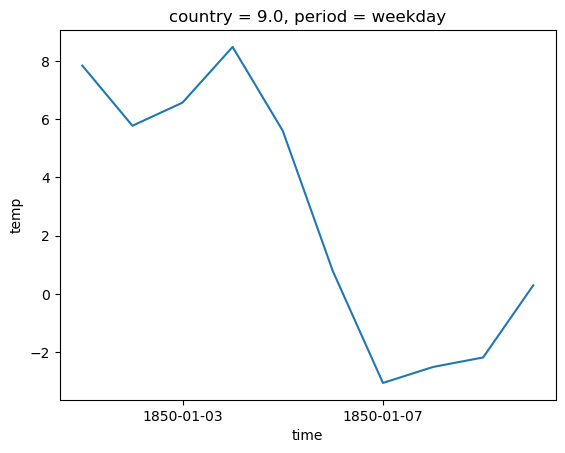

In [28]:
ds_demand_actual['temp'][0:10].plot()

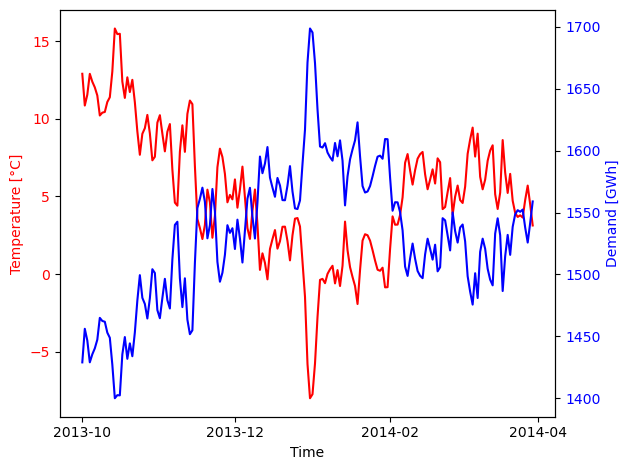

In [32]:
# Plot time series (time against temp and demand)
fig, ax1 = plt.subplots()

a = 191 + 365 * 81
b = 7 + 365 * 82

# Plot temperature on the first y-axis
ax1.plot(ds_demand['time'][a:b], ds_demand['temp'][a:b], label='Temperature', color='r')
ax1.set_ylabel('Temperature [°C]', color='r')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis to plot demand
ax2 = ax1.twinx()
ax2.plot(ds_demand_actual['time'][a:b], ds_demand_actual['demand'][a:b], label='Demand', color='b')
ax2.set_ylabel('Demand [GWh]', color='b')
ax2.tick_params(axis='y', labelcolor='b')

fig.tight_layout()
plt.show()

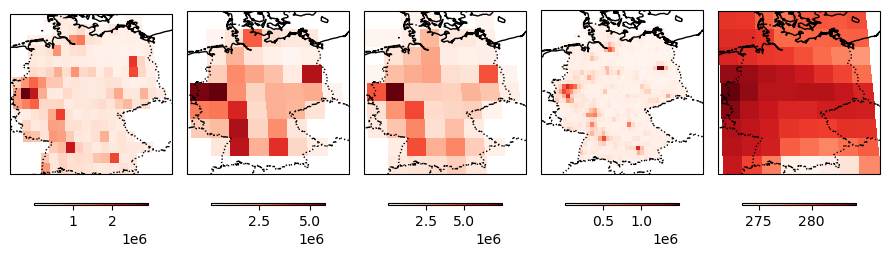

In [ ]:
tst = tas.sel(dict(lat=slice(s,n), lon=slice(w, e), time='1850-01-01 00:00:00'))

lon_edges = tst.lon.values - (tst.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = tst.lat.values - (tst.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(nrows=1, ncols=5, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = population_isimip_subset
im1 = ax1.pcolormesh(population_isimip_subset.lon, population_isimip_subset.lat, xxx1, transform=ccrs.PlateCarree(), cmap='Reds')
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = population_regrid_ISIMIP_slice
im2 = ax2.pcolormesh(population_regrid_ISIMIP_slice.lon, population_regrid_ISIMIP_slice.lat, xxx2, transform=ccrs.PlateCarree(), cmap='Reds')
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = population_regrid_vdW_slice
im3 = ax3.pcolormesh(population_regrid_vdW_slice.lon, population_regrid_vdW_slice.lat, xxx3, transform=ccrs.PlateCarree(), cmap='Reds')
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

# Fourth subplot
ax4.coastlines()
ax4.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx4 = demand_population_t2m_grid_de
im4 = ax4.pcolormesh(demand_population_t2m_grid_de.lon, demand_population_t2m_grid_de.lat, xxx4, transform=ccrs.PlateCarree(), cmap='Reds')
cbar4 = fig.colorbar(im4, ax=ax4, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

# Fifth subplot
ax5.coastlines()
ax5.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx5 = tst.isel(time=0)
im5 = ax5.pcolormesh(tst.lon, tst.lat, xxx5, transform=ccrs.PlateCarree(), cmap='Reds')
cbar5 = fig.colorbar(im5, ax=ax5, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

plt.tight_layout()
plt.show()

In [ ]:
weights = demand_population_t2m_grid_weights.sel( dict(country = 9, lat=slice(60,45), lon=slice(5,15)))['population']

In [ ]:
# Load solar power data (mainly for the grid)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_power.nc')


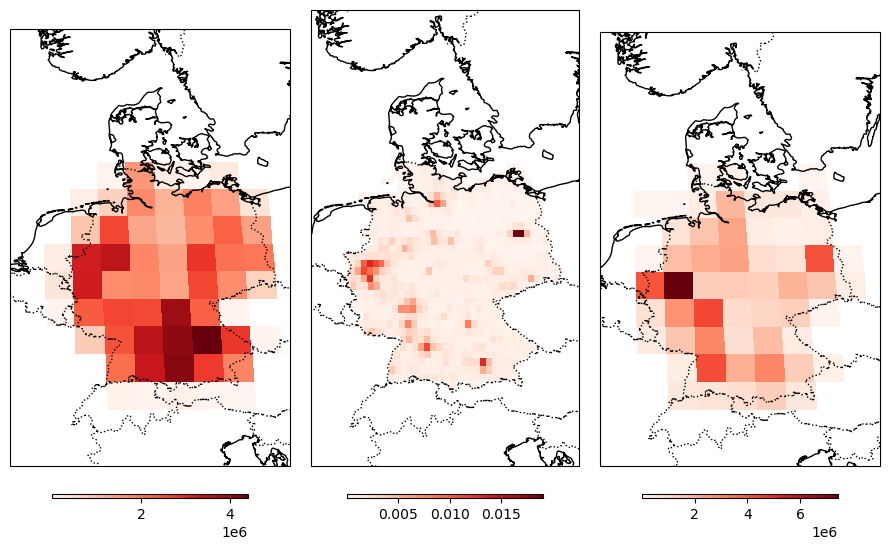

In [ ]:
lon_edges = grid_solar.lon.values - (grid_solar.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid_solar.lat.values - (grid_solar.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = grid_solar['solar_cap']
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds')
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = weights
im2 = ax2.pcolormesh(weights.lon, weights.lat, xxx2, transform=ccrs.PlateCarree(), cmap='Reds')
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = population_regrid_slice
im3 = ax3.pcolormesh(population_regrid_slice.lon, population_regrid_slice.lat, xxx3, transform=ccrs.PlateCarree(), cmap='Reds')
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)


plt.tight_layout()
plt.show()

In [ ]:
lon_edges = grid_solar.lon.values - (grid_solar.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid_solar.lat.values - (grid_solar.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')


tas_lat_extended = np.append(lat_edges, lat_edges[15] + lat_edges[2] - lat_edges[1])
tas_lon_extended = np.append(lon_edges, lon_edges[8] + 1.25)


In [ ]:
from xhistogram.xarray import histogram

# Define bin edges based on low-resolution lat/lon
lat = tas_lat_extended # tas.lat#np.linspace(45, 60, 17)  # 16 bins, so 17 edges
lon = tas_lon_extended # tas.lon # np.linspace(5, 15, 10)   # 9 bins, so 10 edges

# Compute the sum within each bin
low_res_data = histogram(weights.lat, weights.lon, bins=[lat, lon], weights=weights)


In [ ]:
weights_low_res_data = low_res_data * (1 / low_res_data.sum())

In [ ]:
weights_low_res_data = weights_low_res_data.rename({'lat_bin': 'lat', 'lon_bin': 'lon'})
weights_low_res_data

<xarray.DataArray 'histogram_lat_lon' (lat: 16, lon: 9)> Size: 1kB
array([[       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan],
       [       nan,        nan,        nan, 0.07153573, 0.03512834,
        0.0508543 , 0.023301  ,        nan,        nan],
       [       nan,        nan, 0.02666791, 0.05032212, 0.01562212,
        0.02994189,        nan,        nan,        nan],
       [       nan,        nan, 0.04580297, 0.0726667 , 0.01754978,
        0.01988835,        nan,        nan,        nan],
       [       nan,        nan, 0.1229145 , 0.02259542, 0.02311311,
        0.02169762, 0.03324458, 0.02650921,        nan],
       [       nan,        nan,        nan, 0.03637601, 0.0404029 ,
        0.01673805, 0.01340811, 0.0696902 ,        nan],
       [       nan,        nan,        nan, 0.02702713, 0.03967942,
        0.0060558 , 0.00387226, 0.005002  ,        nan],
       [       nan,        nan,        nan,        nan, 0.03239248,
               nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan]])
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0

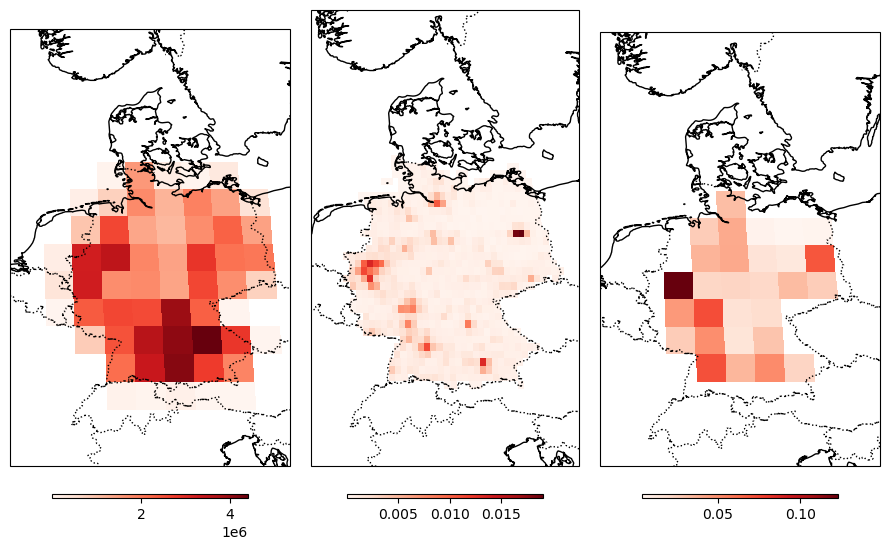

In [ ]:
lon_edges = grid_solar.lon.values - (grid_solar.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid_solar.lat.values - (grid_solar.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = grid_solar['solar_cap']
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds')
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = weights
im2 = ax2.pcolormesh(weights.lon, weights.lat, xxx2, transform=ccrs.PlateCarree(), cmap='Reds')
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = weights_low_res_data
im3 = ax3.pcolormesh(weights_low_res_data.lon, weights_low_res_data.lat, xxx3, transform=ccrs.PlateCarree(), cmap='Reds')
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)


plt.tight_layout()
plt.show()

In [ ]:
ds_t2m = tas

In [ ]:
weights_low_res_data['lat'] = ds_t2m.lat

In [ ]:
tst = (ds_t2m.sel(time=str(1850)) * weights_low_res_data)

In [ ]:
tst.lat

<xarray.DataArray 'lat' (lat: 16)> Size: 128B
array([45.706806, 46.649215, 47.591623, 48.534031, 49.47644 , 50.418848,
       51.361257, 52.303665, 53.246073, 54.188482, 55.13089 , 56.073298,
       57.015707, 57.958115, 58.900524, 59.842932])
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
Attributes:
    axis:           Y
    bounds:         lat_bnds
    standard_name:  latitude
    title:          Latitude
    type:           double
    units:          degrees_north
    valid_max:      90.0
    valid_min:      -90.0

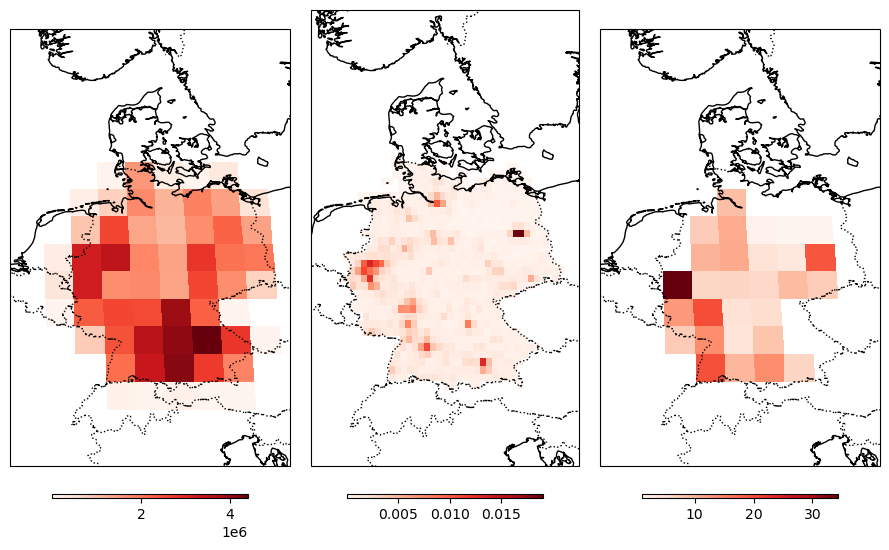

In [ ]:
lon_edges = grid_solar.lon.values - (grid_solar.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid_solar.lat.values - (grid_solar.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = grid_solar['solar_cap']
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds')
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = weights
im2 = ax2.pcolormesh(weights.lon, weights.lat, xxx2, transform=ccrs.PlateCarree(), cmap='Reds')
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = tst.isel(time=1)
im3 = ax3.pcolormesh(lon_edges, lat_edges, xxx3, transform=ccrs.PlateCarree(), cmap='Reds')
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)


plt.tight_layout()
plt.show()

In [ ]:
demand_list = []
for y in np.unique(ds_t2m["time.year"].values)[0:2]:
    print(y)
    ds_demand0 = xr.Dataset()
    # weighted temperature
    ds_demand0["temp"] = (ds_t2m.sel(time=str(y)) * weights_low_res_data).sum(
        dim=["lat", "lon"], keep_attrs=True
    )
    demand_list.append(ds_demand0)
# concat years together again
ds_demand = xr.concat(demand_list, dim="time") 

1850
1851


In [ ]:
ds_demand = xr.concat(
    [
        ds_demand.where(ds_demand["time.dayofweek"] < 5, drop=True),
        ds_demand.where(ds_demand["time.dayofweek"] >= 5, drop=True),
    ],
    "period",
)
# select only the countries for which we have fitted data:
ds_demand["period"] = ["weekday", "weekend"]

In [ ]:
ds_demand

<xarray.Dataset> Size: 9kB
Dimensions:  (period: 2, time: 364)
Coordinates:
  * time     (time) object 3kB 1850-01-01 00:00:00 ... 1851-12-31 00:00:00
  * period   (period) <U7 56B 'weekday' 'weekend'
Data variables:
    temp     (period, time) float64 6kB dask.array<chunksize=(1, 1), meta=np.ndarray>

In [ ]:

# select only the countries for which we have fitted data:
# select only the countries for which we have fitted data and for which we have climate data:
demand_countries = [f for f in fv.country.data if f in ds_demand.country.values]
ds_demand = ds_demand.sel(country=demand_countries)
fv = fv.sel(country=demand_countries)

# compute demand with fit variables
ds_demand = demand.compute_demand(ds_demand, fv)
# remove period dimension
ds_demand = xr.concat([ds_demand.isel(period=0), ds_demand.isel(period=1)], "time")
# update attributes
ds_demand = attributes.set_global_attributes(
    ds_demand, "Entsoe-ERA5 fit and HW3", grid="gaussian n80", area="Europe"
)

# clean file
ds_demand["demand"] = ds_demand.demand.transpose("time", "country")
ds_demand = ds_demand.drop("period").dropna(dim="time")
# sort the weekend and weekday demand by time
ds_demand = ds_demand.sortby("time")
# save file
ds_demand.to_netcdf(dir_demand + os.path.basename(tempf).replace(var1, "demand"))
print("done with :" + os.path.basename(tempf).replace(var1, "demand"))

<xarray.Dataset> Size: 9kB
Dimensions:  (period: 2, time: 364)
Coordinates:
  * time     (time) object 3kB 1850-01-01 00:00:00 ... 1851-12-31 00:00:00
Dimensions without coordinates: period
Data variables:
    temp     (period, time) float64 6kB dask.array<chunksize=(1, 1), meta=np.ndarray>

In [ ]:
# split run over years to reduce memory usage
demand_list = []
for y in np.unique(ds_t2m["time.year"].values):
    print(y)
    ds_demand0 = xr.Dataset()
    # weighted temperature
    ds_demand0["temp"] = (ds_t2m.sel(time=str(y)) * weights.population).sum(
        dim=["lat", "lon"], keep_attrs=True
    )
    demand_list.append(ds_demand0)
# concat years together again
ds_demand = xr.concat(demand_list, dim="time") 

# to match dimensions of fitvalues (country,period) per weekend and weekday
ds_demand = xr.concat(
    [
        ds_demand.where(ds_demand["time.dayofweek"] < 5, drop=True),
        ds_demand.where(ds_demand["time.dayofweek"] >= 5, drop=True),
    ],
    "period",
)

1850


AttributeError: 'DataArray' object has no attribute 'population'

In [ ]:

# select only the countries for which we have fitted data:
ds_demand["period"] = ["weekday", "weekend"]
# select only the countries for which we have fitted data:
# select only the countries for which we have fitted data and for which we have climate data:
demand_countries = [f for f in fv.country.data if f in ds_demand.country.values]
ds_demand = ds_demand.sel(country=demand_countries)
fv = fv.sel(country=demand_countries)

# compute demand with fit variables
ds_demand = demand.compute_demand(ds_demand, fv)
# remove period dimension
ds_demand = xr.concat([ds_demand.isel(period=0), ds_demand.isel(period=1)], "time")
# update attributes
ds_demand = attributes.set_global_attributes(
    ds_demand, "Entsoe-ERA5 fit and HW3", grid="gaussian n80", area="Europe"
)

# clean file
ds_demand["demand"] = ds_demand.demand.transpose("time", "country")
ds_demand = ds_demand.drop("period").dropna(dim="time")
# sort the weekend and weekday demand by time
ds_demand = ds_demand.sortby("time")
# save file
ds_demand.to_netcdf(dir_demand + os.path.basename(tempf).replace(var1, "demand"))
print("done with :" + os.path.basename(tempf).replace(var1, "demand"))